In [51]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
warnings.filterwarnings("ignore", message="numpy.ufunc size changed")

In [52]:
import numpy as np 
import TPTBox as tpt
from pathlib import Path
import scipy
import skimage

In [69]:
class Volume:
  def __init__(self,
               path):
    path = Path(path)
    parent = path.parent
    bids_file = tpt.BIDS_FILE(str(path), str(parent))
    self.image = bids_file.open_nii()
    # self.scale = np.array(self.image.GetSpacing())[::-1]
    # print(self.scale)
    # self.affine = self.image.GetDirection()
    self.array = self.image.get_array()
    # print("Label ordering:", np.unique(self.array))

  def get_pcd(self, index=None, return_value=False):
    if index is None:
      pcd = np.stack(np.where(self.array > 0)).T
    else:
      pcd = np.stack(np.where(self.array == index)).T
    values = None
    if return_value is True:
      values = []
      for point in pcd:
        values.append(self.array[point])
      # N-3, N-1
    return pcd, values

  def construct_window(radius=3, mode='cube'):
      """ Constructing window for non-equal supression
      """
      assert radius % 2 != 0
      r = radius // 2
      # add noise to prevent neighbor exclusion
      window = np.ones([radius, radius, radius]) + np.random.randn(radius, radius, radius) * 0.3
      x = np.linspace(-r, r, radius)
      y, z = x.copy(), x.copy()
      xv, yv, zv = np.meshgrid(x, y, z)

      if mode == 'cyclic':
        window[xv**2 + yv**2 + zv**2 >= (r + 0.25) ** 2] = 0
      elif mode == 'cross':
        window *= (xv == 0) | (yv == 0) | (zv == 0)
      elif mode == 'uni-cross':
        x = xv == 0
        y = yv == 0
        z = zv == 0
        window *= (x & y) | (y & z) | (z & x)
      window[r][r][r] = 0
      window[r][r][r] = -np.sum(window)

      return window

  def normalize(self):
      """ Recover 3d volumetric to standard axis spacing of 1
      """
      self.array = scipy.ndimage.zoom(self.array, self.scale, order=0)


  def convex_hull(self, label=0, radius=3, mode='cube', threshold=0.05):
      """ Return hull of a dense volumetric
          Can work on either binary or multiclass mask
      """
      # Radius to determine level of exclusion
      if label == 0:
        arr = self.array.copy()
      else:
        arr = (self.array == label).astype(float)

      convo_window = Volume.construct_window(radius=radius, mode=mode)
      mask = scipy.ndimage.convolve(arr, convo_window, mode='constant')
      optimal = abs(mask) >= threshold
      return optimal.astype(int)

  def reduce(self, radius=3, mode='cube', threshold=1):
      mask = np.zeros_like(self.array)
      for label in np.unique(self.array):
        if label == 0: 
          continue
        mask += self.convex_hull( label=label, radius=radius, mode=mode, threshold=threshold)
      mask = (mask > 0).astype(float)
      # Make sure that 
      self.array = mask

In [64]:
path = "/work/hpc/spine-segmentation/data/dataset/spine_nii/masks/1_t1.nii.gz"

In [65]:
volume = Volume(path)

[!] "1" is not a valid key/value pair. Expected "KEY-VALUE" in 1_t1.nii.gz
Label ordering: [  0   1   2   3   4   5   6   7 100 201 202 203 204 205 206 207]


In [ ]:
img_volume = Volume()

In [56]:
volume.reduce(radius=3, mode='cross', threshold=0.05)

KeyboardInterrupt: 

In [ ]:
import torch 
import FastGeodis as geo 

In [83]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [70]:
img = Volume("/work/hpc/spine-segmentation/data/dataset/spine_nii/images/1_t1.nii.gz")
mask = Volume("/work/hpc/spine-segmentation/data/dataset/spine_nii/masks/1_t1.nii.gz")
# img = sitk.GetArrayFromImage()

[!] "1" is not a valid key/value pair. Expected "KEY-VALUE" in 1_t1.nii.gz


[!] "1" is not a valid key/value pair. Expected "KEY-VALUE" in 1_t1.nii.gz


In [59]:
spacing = volume.image.zoom
spacing

(3.3211472, 0.625, 0.5006067)

In [ ]:
geo.generalised_geodesic3d?

Signature:
geo.generalised_geodesic3d(
    image: torch.Tensor,
    softmask: torch.Tensor,
    spacing: List,
    v: float,
    lamb: float,
    iter: int = 4,
)
Docstring:
Computes Generalised Geodesic Distance using FastGeodis raster scanning.
For more details on generalised geodesic distance, check the following reference:

Criminisi, Antonio, Toby Sharp, and Andrew Blake.
"Geos: Geodesic image segmentation."
European Conference on Computer Vision, Berlin, Heidelberg, 2008.

The function expects input as torch.Tensor, which can be run on CPU or GPU depending on Tensor's device location

Args:
    image: input image, can be grayscale or multiple channels.
    softmask: softmask in range [0, 1] with seed information.
    spacing: spacing for 3D data
    v: weighting factor for establishing relationship between unary and spatial distances.
    lamb: weighting factor between 0.0 and 1.0. 0.0 returns euclidean distance, whereas 1.0 returns geodesic distance
    iter: number of passes of

In [ ]:
img = sitk

In [111]:
arr = torch.from_numpy(img.image.get_array().astype(np.float32)).unsqueeze_(0).unsqueeze_(0)
mask_arr = 1 - torch.from_numpy((mask.array > 0).astype(np.float32)).unsqueeze_(0).unsqueeze_(0)
v = 1e10
it = 2
lamb = 1.0

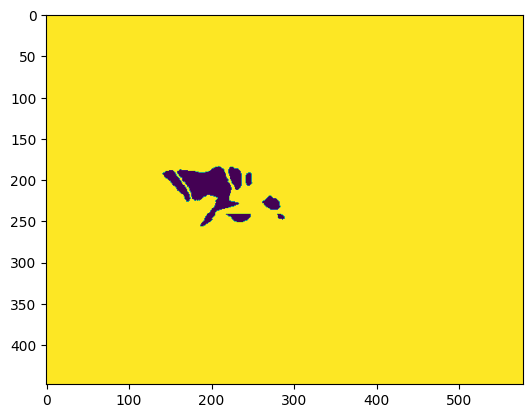

In [112]:
plt.imshow(mask_arr[0, 0, 15])

In [113]:
arr.shape, mask_arr.shape, spacing

(torch.Size([1, 1, 50, 448, 578]),
 torch.Size([1, 1, 50, 448, 578]),
 (3.3211472, 0.625, 0.5006067))

In [108]:
geo_dist = geo.generalised_geodesic3d(arr, mask_arr, spacing, v, 0.0, 10)

In [109]:
volume.image.set_array_(geo_dist.squeeze().numpy())

shp=(50, 448, 578); ori=('L', 'P', 'S'), zoom=(3.32, 0.62, 0.5), seg=False

In [110]:
volume.image.save("/work/hpc/spine-segmentation/outputs/dummy/distance_map.nii.gz")

[*] Save /work/hpc/spine-segmentation/outputs/dummy/distance_map.nii.gz as float32


In [ ]:
print("1")

1


In [ ]:
geo_dist = geo_dist.squeeze()

In [ ]:
geo_dist.size()

torch.Size([50, 448, 578])

shp=(50, 448, 578); ori=('L', 'P', 'S'), zoom=(3.32, 0.62, 0.5), seg=False

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.imshow(np.sum(volume.array, axis=0))

In [ ]:
np.mean(volume.array)

In [ ]:
np.unique(volume.array)

In [ ]:
convo_window = Volume.construct_window(radius=5, mode='cross')
np.sum(convo_window)

In [ ]:
def gaussian_kernel(radius=3, dim=3, delta=0.8):

    mean = radius // 2 + ((radius + 1) % 2) / 2 

    coef = np.identity(dim) * np.power(delta, 2)
    inv_coef = np.linalg.inv(coef)

    denominator = (2 * np.pi * (delta ** 2)) ** (dim / 2)

    grid = np.arange(radius)
    mesh = np.array(np.meshgrid(*[grid] * dim)) - mean

    mesh = np.apply_along_axis(lambda x: np.exp( - 0.5 * x.T @ inv_coef @ x ), 0, mesh) / denominator
    return mesh

In [ ]:
img = gaussian_kernel(radius=5, dim=1)

In [ ]:
print(img.shape, np.sum(img))
print(img)

[*] Save /work/hpc/spine-segmentation/outputs/dummy/distance_map.nii.gz as float32


In [ ]:
import plotly
from plotly import  graph_objects as go

In [ ]:
pcd, values = volume.get_pcd( return_value=False)

In [ ]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pcd[:, 0], y=pcd[:, 1], z=pcd[:, 2],
            mode='markers',
            marker=dict(size=1, color=(1, 0, 0)),

        )
    ],
    layout = dict(title=dict(text="Normalized and Reduced Mask Point Cloud"))
)
fig.show()

In [ ]:
volume.image.set_array_(volume.array)

In [ ]:
arr = volume.image.get_array()

In [ ]:
pcd = np.stack(np.where(arr > 0)).T

In [ ]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pcd[:, 0], y=pcd[:, 1], z=pcd[:, 2],
            mode='markers',
            marker=dict(size=1, color=(1, 0, 0)),

        )
    ],
    layout = dict(title=dict(text="Test updated point cloud"))
)
fig.show()

In [ ]:
volume.image.save("/work/hpc/spine-segmentation/outputs/dummy/laplace_1.nii.gz")

In [ ]:
folder = "/work/hpc/spine-segmentation/data/dataset/spine_nii/masks"
out_folder = "/work/hpc/spine-segmentation/data/dataset/spine_nii/border"

In [ ]:
import os

In [ ]:
for filename in os.listdir(folder):
    path = os.path.join(folder, filename)
    volume = Volume(path)
    volume.reduce(radius=3, mode='cyclic', threshold=0.05)
    volume.image.set_array_(volume.array)
    volume.image.save(os.path.join(out_folder, filename))